<a href="https://colab.research.google.com/github/Apekshya175/AI-ML/blob/main/Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

tf.config.experimental.enable_op_determinism()

print("Global seed set to:", SEED)

Global seed set to: 123


In [ ]:
import math
import zipfile
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Define paths


In [ ]:
train_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/test"

Read class names

In [ ]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Class directories found:")
print(class_names)
print("Total number of classes:", len(class_names))

Class directories found:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total number of classes: 6


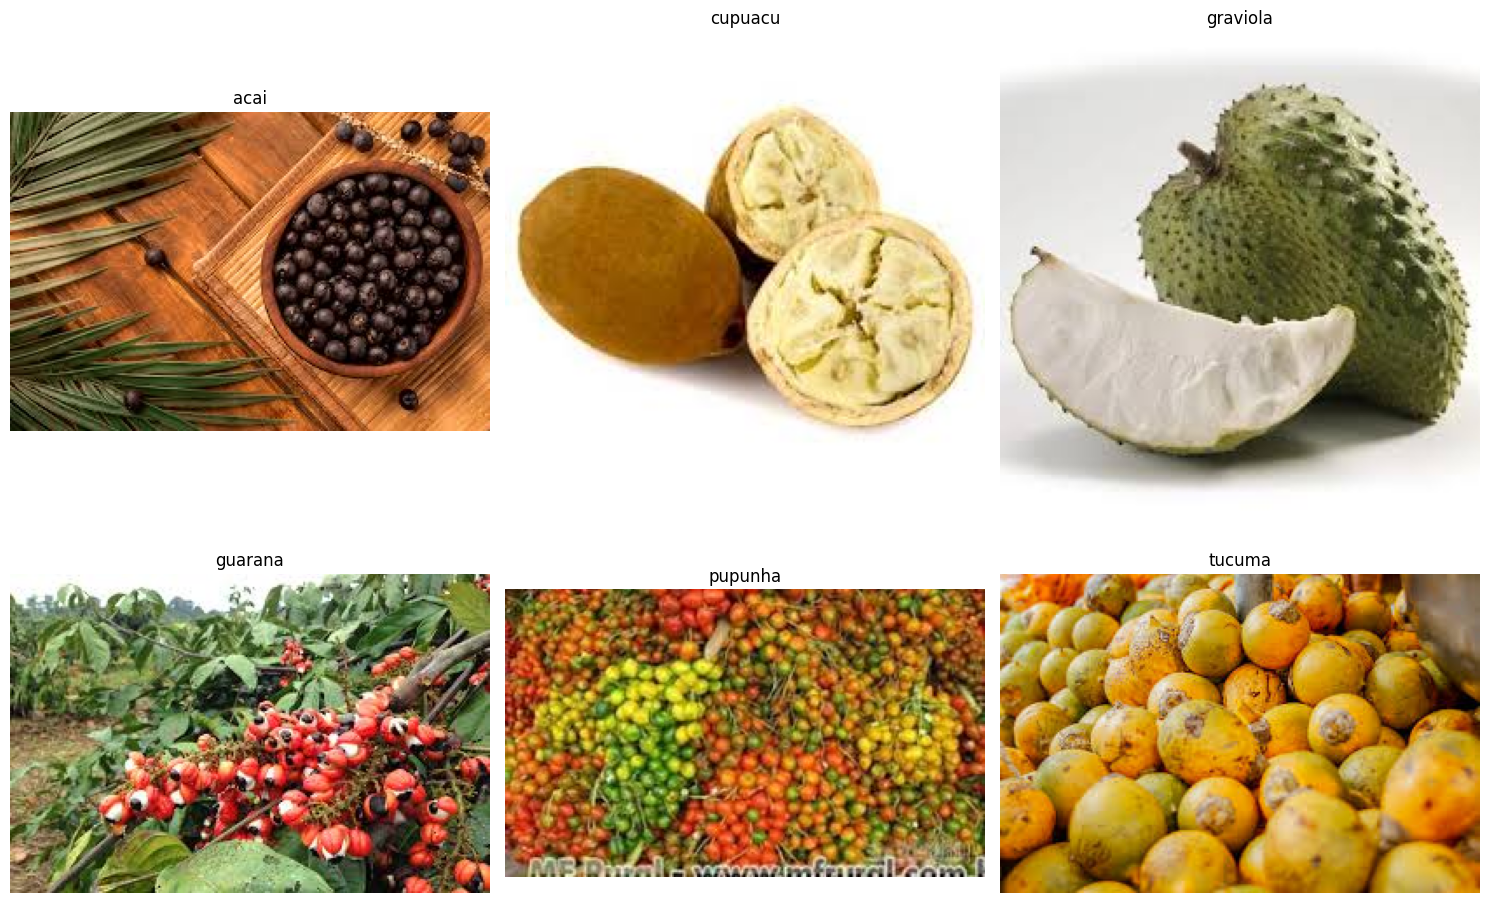

In [ ]:
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    image_files = sorted([
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ])

    if len(image_files) > 0:
        random_image = random.choice(image_files)
        image_path = os.path.join(class_path, random_image)
        sample_images.append((class_name, image_path))

rows = 2
cols = math.ceil(len(sample_images) / rows)

plt.figure(figsize=(5 * cols, 5 * rows))
for i, (class_name, image_path) in enumerate(sample_images, 1):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

Remove corrupt images

In [ ]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)

        if os.path.isfile(file_path):
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError, UnidentifiedImageError):
                corrupted_images.append(file_path)
                os.remove(file_path)
                print(f"Removed corrupted image: {file_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print("Total corrupted images removed:", len(corrupted_images))

No corrupted images found.


Count images in each class

In [ ]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp'))
    ]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name:<20} {count:>5}")



Class Distribution:
acai                    15
cupuacu                 15
graviola                15
guarana                 15
pupunha                 15
tucuma                  15


Task 1: Preprocessing with Data Augmentation

In [ ]:
img_height = 128
img_width = 128
batch_size = 8
validation_split = 0.2



In [ ]:
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=SEED
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=SEED
)

raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = raw_train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = raw_val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = raw_test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation_layers = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


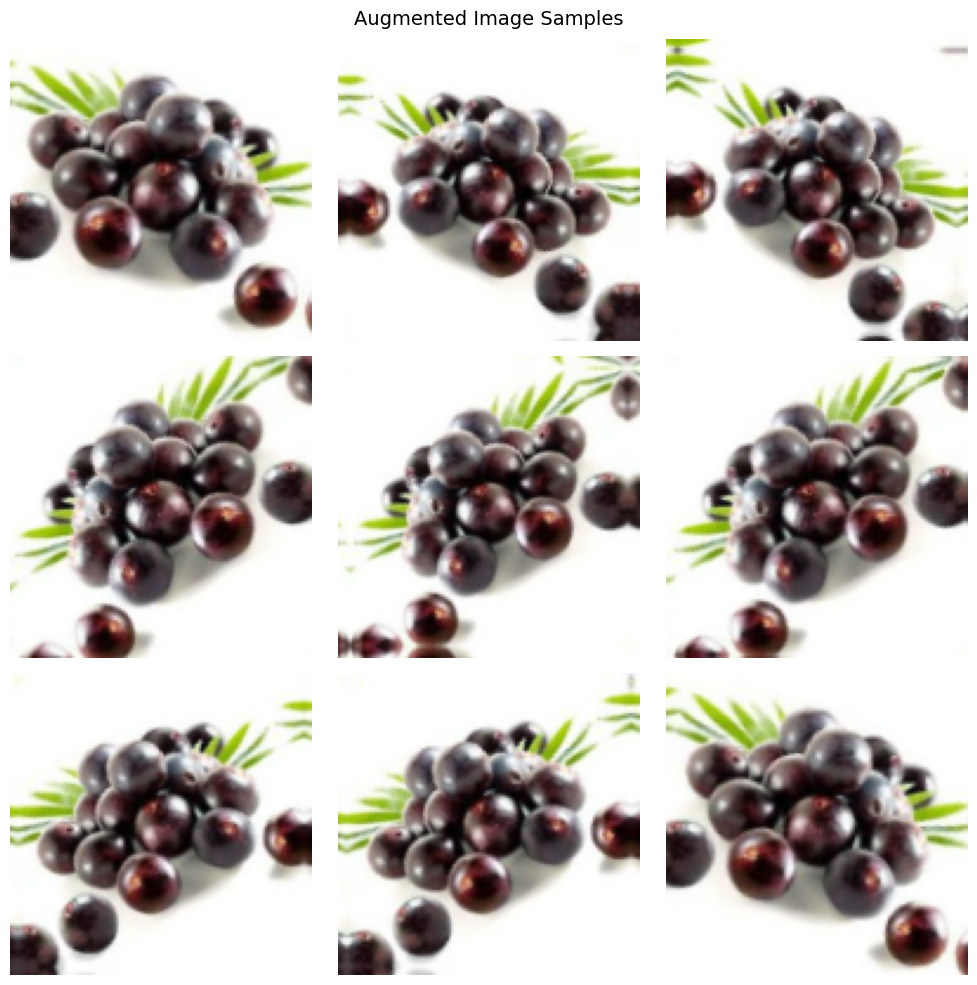

In [ ]:

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation_layers(images, training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

plt.suptitle("Augmented Image Samples", fontsize=14)
plt.tight_layout()
plt.show()

Task2 : Build the CNN model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D

tf.keras.backend.clear_session()

model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Data augmentation and normalization
    data_augmentation_layers,   # ← pass as single layer, no * unpacking
    layers.Rescaling(1./255),

    # Convolutional Blocks
    Conv2D(32, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    # Classification Head
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,894 (398.02 KB)

 Trainable params: 101,894 (398.02 KB)

 Non-trainable params: 0 (0.00 B)

Task 3 : Compile the CNN model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint_cb = ModelCheckpoint(
    'best_fruit_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

Task 4 : Train the model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0988 - loss: 1.8176
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_model_v2.keras

Epoch 1: finished saving model to best_fruit_model_v2.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.1250 - loss: 1.8070 - val_accuracy: 0.0000e+00 - val_loss: 1.8912
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2074 - loss: 1.7810
Epoch 2: val_accuracy did not improve from 0.00000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.1806 - loss: 1.7795 - val_accuracy: 0.0000e+00 - val_loss: 1.8860
Epoch 3/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1835 - loss: 1.7801
Epoch 3: val_accuracy did not improve from 0.00000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.1667 - loss: 1.7641 - val_accuracy: 0.0000e+00 - val_loss: 1.9147
Epoch 4/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3351 - loss: 1.7291
Epoch 4: val_accuracy improved from 0.00000 to 0.22

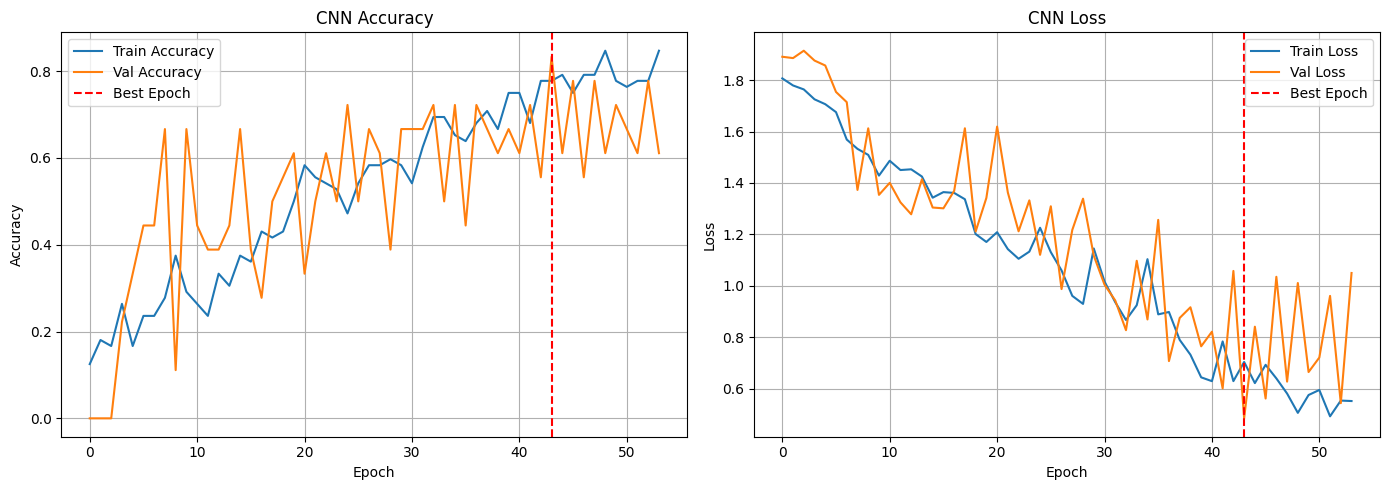

In [ ]:
best_epoch = np.argmin(history.history['val_loss'])

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
train_loss, train_accuracy = model.evaluate(train_ds, verbose=0)
val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print("\n=== CNN Performance ===")
print(f"Train Accuracy      : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Train Loss          : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")


=== CNN Performance ===
Train Accuracy      : 0.8056
Validation Accuracy : 0.8333
Test Accuracy       : 0.7333
Train Loss          : 0.5598
Validation Loss     : 0.4839
Test Loss           : 0.8467


In [ ]:
y_true_cnn = []
y_pred_cnn = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_cnn.extend(labels.numpy())
    y_pred_cnn.extend(predicted_labels)

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

print("Improved CNN Classification Report:\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

Improved CNN Classification Report:

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.67      0.80      0.73         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.78      0.73      0.72        30
weighted avg       0.78      0.73      0.72        30



Part 1: Load datasets for VGG16

In [ ]:
img_h_vgg = 224
img_w_vgg = 224
batch_size_vgg = 8
validation_split = 0.2

raw_train_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_h_vgg, img_w_vgg),
    batch_size=batch_size_vgg,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=SEED
)

raw_val_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_h_vgg, img_w_vgg),
    batch_size=batch_size_vgg,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=SEED
)

raw_test_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_h_vgg, img_w_vgg),
    batch_size=batch_size_vgg,
    shuffle=False
)

class_names = raw_train_vgg.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_for_vgg(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_ds_vgg = raw_train_vgg.map(preprocess_for_vgg, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_vgg   = raw_val_vgg.map(preprocess_for_vgg, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_vgg  = raw_test_vgg.map(preprocess_for_vgg, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Part 2: Load VGG16 base model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model, Input

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(img_h_vgg, img_w_vgg, 3)
)

base_model.trainable = False

inputs = Input(shape=(img_h_vgg, img_w_vgg, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,783,174 (56.39 MB)

 Trainable params: 67,462 (263.52 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

Part 4: Compile the model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop_1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history1 = model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=15,
    callbacks=[early_stop_1, reduce_lr_1]
)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.1667 - loss: 2.5768 - val_accuracy: 0.1111 - val_loss: 4.7582 - learning_rate: 1.0000e-04
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.1528 - loss: 2.6862 - val_accuracy: 0.1111 - val_loss: 3.6408 - learning_rate: 1.0000e-04
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.1389 - loss: 2.5090 - val_accuracy: 0.1667 - val_loss: 3.0609 - learning_rate: 1.0000e-04
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.1667 - loss: 2.3563 - val_accuracy: 0.1667 - val_loss: 2.6719 - learning_rate: 1.0000e-04
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.2778 - loss: 2.0197 - val_accuracy: 0.1667 - val_loss: 2.3831 - learning_rate: 1.0000e-04
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.3194 - loss: 2.0664 - val_accuracy: 0.1667 - val_loss: 2.1390 - learning_rate: 1.0000e-04
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.3056 - loss: 1

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop_2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history2 = model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=10,
    callbacks=[early_stop_2, reduce_lr_2]
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.5139 - loss: 1.2625 - val_accuracy: 0.7778 - val_loss: 0.8736 - learning_rate: 1.0000e-05
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.6389 - loss: 0.9542 - val_accuracy: 0.8889 - val_loss: 0.6910 - learning_rate: 1.0000e-05
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7222 - loss: 0.7413 - val_accuracy: 0.8889 - val_loss: 0.5821 - learning_rate: 1.0000e-05
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8056 - loss: 0.5747 - val_accuracy: 0.8889 - val_loss: 0.4922 - learning_rate: 1.0000e-05
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.8611 - loss: 0.4612 - val_accuracy: 0.8889 - val_loss: 0.4368 - learning_rate: 1.0000e-05
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8472 - loss: 0.5326 - val_accuracy: 0.8889 - val_loss: 0.4145 - learning_rate: 1.0000e-05
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9028 - loss: 0.39

In [ ]:
val_loss, val_acc = model.evaluate(val_ds_vgg, verbose=1)
test_loss, test_acc = model.evaluate(test_ds_vgg, verbose=1)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8889 - loss: 0.3577
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7333 - loss: 0.9519
Validation Accuracy: 0.8889
Test Accuracy: 0.7333


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds_vgg:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.56      1.00      0.71         5
     guarana       1.00      0.60      0.75         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.57      0.80      0.67         5

    accuracy                           0.73        30
   macro avg       0.82      0.73      0.73        30
weighted avg       0.82      0.73      0.73        30

